# Elementy odstające (*outliers*)

> **Kontekst ćwiczeń:** Pracujemy z danymi sprzedażowymi sklepu internetowego.  
> Cel: zidentyfikować nietypowe obserwacje, zrozumieć ich przyczyny  
> i podjąć decyzję — usunąć, skorygować czy zachować.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_rows', 40)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

np.random.seed(42)

## Czym są elementy odstające?

**Element odstający (outlier)** to obserwacja, która znacząco odbiega od pozostałych danych. Może wynikać z:

- **błędu pomiaru / wpisu** — literówka, awaria czujnika, podwójne zaksięgowanie
- **rzeczywistego zdarzenia** — wyprzedaż Black Friday, awaria serwera, viralowy post
- **zmiany procesu** — nowa kampania reklamowa, zmiana cen, wejście na nowy rynek

### Dlaczego to ważne?

Outliersy mogą poważnie wpływać na analizę statystyczną i modele predykcyjne:
średnia arytmetyczna, odchylenie standardowe, regresja liniowa — wszystko to jest
wrażliwe na wartości ekstremalne. Jednocześnie outliersy mogą nieść
**cenną informację biznesową**, więc nie zawsze należy je usuwać.

## Typy elementów odstających

| Typ | Opis | Przykład |
|-----|------|---------|
| **Jednowymiarowy** | Ekstremalna wartość jednej zmiennej | Sprzedaż 5× wyższa niż zwykle |
| **Wielowymiarowy** | Nietypowa kombinacja zmiennych (każda z osobna OK) | Klient 22-letni z dochodem 500 tys. zł |
| **Kontekstowy** | Wartość normalna w jednym kontekście, odstająca w innym | 200 sztuk w poniedziałek vs 200 sztuk w niedzielę |

## Metody wykrywania elementów odstających

| # | Metoda | Typ | Założenia |
|---|--------|-----|-----------|
| 1 | Wykres pudełkowy (Boxplot) | wizualna | brak |
| 2 | Metoda IQR | statystyczna, nieparametryczna | brak |
| 3 | Z-score | statystyczna, parametryczna | rozkład normalny |
| 4 | Zmodyfikowany Z-score (MAD) | statystyczna, odporna (robust) | brak |
| 5 | Percentyle | statystyczna, nieparametryczna | brak |

## Przykład

In [13]:
# Wynagrodzenia brutto (tys. zł) — 24 pracowników małej firmy IT
df = pd.DataFrame({
    'pracownik': [
        'Anna', 'Bartek', 'Celina', 'Dawid', 'Ewa',       # juniorzy
        'Filip', 'Gosia', 'Hubert', 'Iwona', 'Jakub',      # regularni
        'Kasia', 'Lena', 'Marcin', 'Natalia', 'Oskar',     # regularni
        'Patryk', 'Robert', 'Sylwia', 'Tomek', 'Urszula',  # seniorzy
        'Wiktor',                                            # kierownik działu
        'Zuzia',                                             # stażystka (pół etatu?)
        'Dyrektor',                                          # CEO
        'Gosia_2',                                           # ← błąd wpisu: 5.5 → 55.0
    ],
    'wynagrodzenie': [
        4.2, 4.5, 4.8, 5.0, 5.1,
        5.3, 5.5, 5.5, 5.8, 6.0,
        6.2, 6.3, 6.5, 6.8, 7.0,
        7.2, 7.5, 8.0, 8.5, 9.0,
        12.0,
        1.8,
        25.0,
        55.0,
    ]
})

wyn = df['wynagrodzenie']

print("DANE: wynagrodzenia pracowników (tys. zł)")
print("=" * 50)
print(df.to_string(index=False))
print(f"\nLiczba obserwacji: {len(df)}")

wyn = df['wynagrodzenie']
print(f"\nŚrednia:  {wyn.mean():.2f} tys. zł")
print(f"Mediana:  {wyn.median():.2f} tys. zł")
print(f"Std:      {wyn.std():.2f} tys. zł")
print(f"Min:      {wyn.min():.2f} tys. zł")
print(f"Max:      {wyn.max():.2f} tys. zł")

print(f"\n→ Średnia ({wyn.mean():.1f}) jest wyraźnie wyższa od mediany ({wyn.median():.1f})")
print("  — to już sygnał, że w danych mogą być outliersy górne!")

DANE: wynagrodzenia pracowników (tys. zł)
pracownik  wynagrodzenie
     Anna           4.20
   Bartek           4.50
   Celina           4.80
    Dawid           5.00
      Ewa           5.10
    Filip           5.30
    Gosia           5.50
   Hubert           5.50
    Iwona           5.80
    Jakub           6.00
    Kasia           6.20
     Lena           6.30
   Marcin           6.50
  Natalia           6.80
    Oskar           7.00
   Patryk           7.20
   Robert           7.50
   Sylwia           8.00
    Tomek           8.50
  Urszula           9.00
   Wiktor          12.00
    Zuzia           1.80
 Dyrektor          25.00
  Gosia_2          55.00

Liczba obserwacji: 24

Średnia:  9.10 tys. zł
Mediana:  6.25 tys. zł
Std:      10.67 tys. zł
Min:      1.80 tys. zł
Max:      55.00 tys. zł

→ Średnia (9.1) jest wyraźnie wyższa od mediany (6.2)
  — to już sygnał, że w danych mogą być outliersy górne!


# Boxplot metoda

### Metoda 1: Wykres pudełkowy (Boxplot)

Boxplot wizualizuje rozkład danych przez kwartyle. Elementy poza „wąsami"
(1.5 × IQR od krawędzi pudełka) traktowane są jako potencjalne outliersy.

Jest to jednocześnie **wizualizacja** i **metoda detekcji** — idealna na początek.

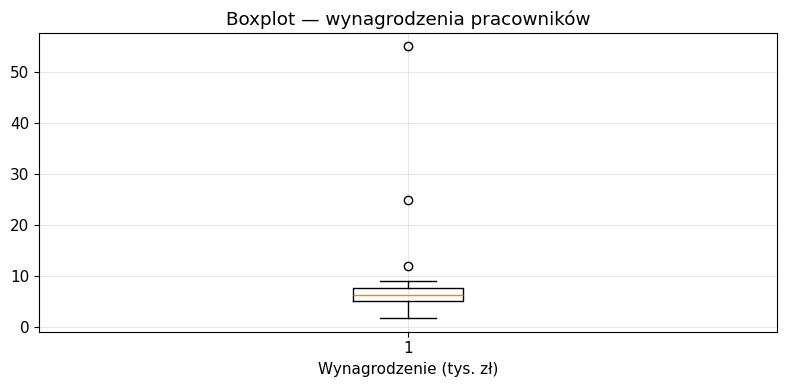

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
bp_vertical = ax.boxplot(df['wynagrodzenie'])
ax.set_xlabel('Wynagrodzenie (tys. zł)')
ax.set_title('Boxplot — wynagrodzenia pracowników')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

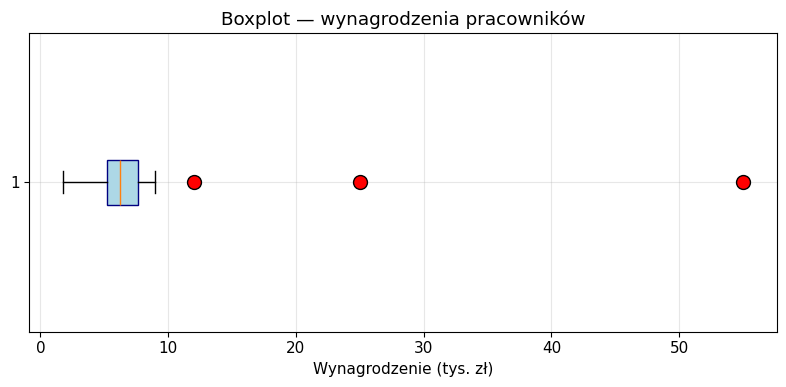

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
bp_horizontal = ax.boxplot(df['wynagrodzenie'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue', edgecolor='navy'),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=10))
ax.set_xlabel('Wynagrodzenie (tys. zł)')
ax.set_title('Boxplot — wynagrodzenia pracowników')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Metoda 2: Rozstęp ćwiartkowy (IQR)

**Wzór:**
$$\text{IQR} = Q_3 - Q_1$$

**Granice:**
- dolna: $Q_1 - 1.5 \times \text{IQR}$
- górna: $Q_3 + 1.5 \times \text{IQR}$

Wartości poza granicami uznajemy za outliersy. Metoda **nieparametryczna** —
nie wymaga rozkładu normalnego. To ta sama logika, którą stosuje boxplot.

In [16]:
wyn = df['wynagrodzenie']
Q1 = wyn.quantile(0.25)
Q3 = wyn.quantile(0.75)
IQR = Q3 - Q1
dolny_limit = Q1 - 1.5 * IQR
gorny_limit = Q3 + 1.5 * IQR

print("METODA IQR")
print("=" * 50)
print(f"Q1 = {Q1:.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"IQR = {IQR:.2f}")
print(f"\nDolny limit = {Q1:.2f} − 1.5 × {IQR:.2f} = {dolny_limit:.2f}")
print(f"Górny limit = {Q3:.2f} + 1.5 × {IQR:.2f} = {gorny_limit:.2f}")

maska_iqr = (wyn < dolny_limit) | (wyn > gorny_limit)
print(f"\nWykryte outliersy ({maska_iqr.sum()}):")
print(df[maska_iqr][['pracownik', 'wynagrodzenie']].to_string(index=False))

METODA IQR
Q1 = 5.25
Q3 = 7.62
IQR = 2.38

Dolny limit = 5.25 − 1.5 × 2.38 = 1.69
Górny limit = 7.62 + 1.5 × 2.38 = 11.19

Wykryte outliersy (3):
pracownik  wynagrodzenie
   Wiktor          12.00
 Dyrektor          25.00
  Gosia_2          55.00


### Metoda 3: Z-score (standaryzacja)

**Wzór:**
$$z_i = \frac{x_i - \bar{x}}{s}$$

Wartość $|z| > 3$ oznacza, że obserwacja leży ponad 3 odchylenia standardowe
od średniej — w rozkładzie normalnym dotyczy to < 0.3% danych.

**Uwaga:** Średnia i odchylenie standardowe **same są wrażliwe na outliersy**,
więc skrajne wartości „rozciągają" skalę i mogą maskować umiarkowane anomalie.

In [17]:
z_scores = np.abs(stats.zscore(wyn))
df['z_score'] = z_scores

print("METODA Z-SCORE")
print("=" * 50)
print(f"Średnia (x̄) = {wyn.mean():.2f}")
print(f"Odch. std (s) = {wyn.std():.2f}")

maska_z3 = z_scores > 3
maska_z2 = z_scores > 2

print(f"\nOutliersy (|z| > 3): {maska_z3.sum()}")
if maska_z3.sum() > 0:
    print(df[maska_z3][['pracownik', 'wynagrodzenie', 'z_score']].to_string(index=False))

print(f"\nPotencjalne outliersy (|z| > 2): {maska_z2.sum()}")
if maska_z2.sum() > 0:
    print(df[maska_z2][['pracownik', 'wynagrodzenie', 'z_score']].to_string(index=False))

print("\n→ Wartość 55.0 (Gosia_2) tak mocno zawyża std,")
print("  że np. Zuzia (1.8) czy Dyrektor (25.0) mogą nie wyjść jako outliersy!")

METODA Z-SCORE
Średnia (x̄) = 9.10
Odch. std (s) = 10.67

Outliersy (|z| > 3): 1
pracownik  wynagrodzenie  z_score
  Gosia_2          55.00     4.39

Potencjalne outliersy (|z| > 2): 1
pracownik  wynagrodzenie  z_score
  Gosia_2          55.00     4.39

→ Wartość 55.0 (Gosia_2) tak mocno zawyża std,
  że np. Zuzia (1.8) czy Dyrektor (25.0) mogą nie wyjść jako outliersy!


### Metoda 4: Zmodyfikowany Z-score (MAD)

Klasyczny Z-score używa średniej i std, które same są wrażliwe na outliersy.
**Zmodyfikowany Z-score** zastępuje je odporniejszymi odpowiednikami:

$$\text{MAD} = \text{median}(|x_i - \widetilde{x}|)$$

$$M_i = \frac{0.6745 \cdot (x_i - \widetilde{x})}{\text{MAD}}$$

Próg: $|M_i| > 3.5$ (zalecenie Iglewicza i Hoaglina, 1993).

Kluczowa różnica: **mediana i MAD nie zmieniają się** pod wpływem jednej
ekstremalnej wartości — dlatego metoda jest **odporna (robust)**.

In [18]:
mediana = wyn.median()
mad = np.median(np.abs(wyn - mediana))
modified_z = np.abs(0.6745 * (wyn - mediana) / mad)
df['mod_z_score'] = modified_z

print("METODA MAD (Zmodyfikowany Z-score)")
print("=" * 50)
print(f"Mediana = {mediana:.2f}")
print(f"MAD     = {mad:.2f}")

maska_mad = modified_z > 3.5
print(f"\nOutliersy (|M| > 3.5): {maska_mad.sum()}")
if maska_mad.sum() > 0:
    print(df[maska_mad][['pracownik', 'wynagrodzenie', 'mod_z_score']].to_string(index=False))

print("\n→ MAD wykrywa więcej anomalii niż Z-score,")
print("  bo Gosia_2 (55.0) nie zaburza miar bazowych.")

METODA MAD (Zmodyfikowany Z-score)
Mediana = 6.25
MAD     = 1.20

Outliersy (|M| > 3.5): 2
pracownik  wynagrodzenie  mod_z_score
 Dyrektor          25.00        10.54
  Gosia_2          55.00        27.40

→ MAD wykrywa więcej anomalii niż Z-score,
  bo Gosia_2 (55.0) nie zaburza miar bazowych.


### Metoda 5: Percentyle

Najprostsza metoda: odcinamy skrajne wartości na wybranym progu procentowym.

- **Rygorystycznie:** poniżej 1. i powyżej 99. percentyla
- **Łagodnie:** poniżej 5. i powyżej 95. percentyla

Metoda przydatna szczególnie przy **winzorowaniu** — zastępowaniu ekstremalnych
wartości wartościami granicznymi.

In [19]:
print("METODA PERCENTYLI")
print("=" * 50)

for dolny_p, gorny_p in [(1, 99), (5, 95)]:
    p_low = wyn.quantile(dolny_p / 100)
    p_high = wyn.quantile(gorny_p / 100)
    maska = (wyn < p_low) | (wyn > p_high)

    print(f"\nPróg {dolny_p}–{gorny_p} percentyl:")
    print(f"  Dolna granica = {p_low:.2f}")
    print(f"  Górna granica = {p_high:.2f}")
    print(f"  Wykryte outliersy: {maska.sum()}")
    if maska.sum() > 0:
        print(df[maska][['pracownik', 'wynagrodzenie']].to_string(index=False))

METODA PERCENTYLI

Próg 1–99 percentyl:
  Dolna granica = 2.35
  Górna granica = 48.10
  Wykryte outliersy: 2
pracownik  wynagrodzenie
    Zuzia           1.80
  Gosia_2          55.00

Próg 5–95 percentyl:
  Dolna granica = 4.25
  Górna granica = 23.05
  Wykryte outliersy: 4
pracownik  wynagrodzenie
     Anna           4.20
    Zuzia           1.80
 Dyrektor          25.00
  Gosia_2          55.00


## Outliersy wielowymiarowe

W praktyce anomalie często ujawniają się dopiero gdy spojrzymy na **kombinację zmiennych**.
Każda zmienna z osobna może wyglądać normalnie, ale ich **połączenie** jest nietypowe.

DANE: doświadczenie vs wynagrodzenie
pracownik  doswiadczenie  wynagrodzenie
     Anna              1           4.50
   Bartek              2           5.00
   Celina              3           5.50
    Dawid              5           6.50
      Ewa              7           7.00
    Filip              8           7.50
    Gosia             10           8.00
   Hubert             12           9.00
    Iwona             15          10.00
    Jakub              3          12.00
    Kasia              6           4.00
     Lena             20           8.00

→ Jakub: 3 lata doświadczenia, a zarabia 12.0 — protegowany?
→ Kasia: 6 lat doświadczenia, a zarabia 4.0 — niedoceniana?
→ Lena: 20 lat i tylko 8.0 — stagnacja?

  Żadna z tych wartości nie jest ekstremalna SAMA W SOBIE,
  ale ich KOMBINACJA jest podejrzana!


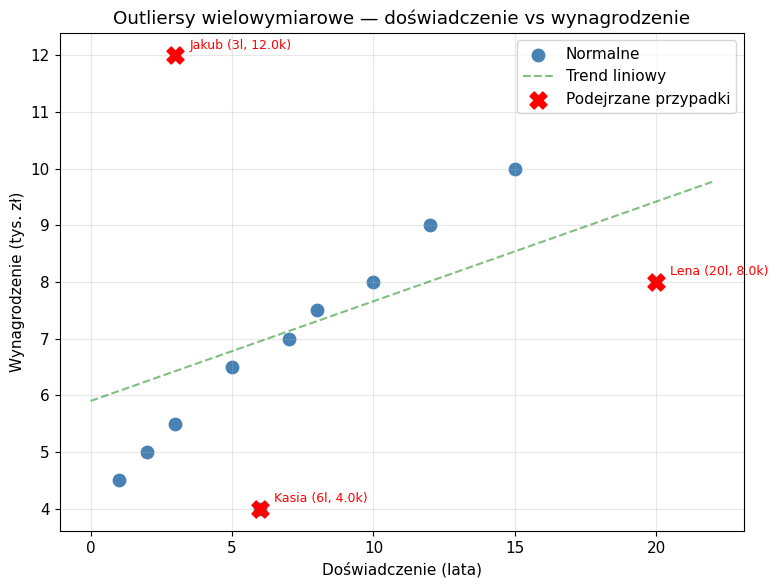

In [20]:
# Dane: doświadczenie (lata) vs wynagrodzenie
df_2d = pd.DataFrame({
    'pracownik': ['Anna', 'Bartek', 'Celina', 'Dawid', 'Ewa',
                   'Filip', 'Gosia', 'Hubert', 'Iwona', 'Jakub',
                   'Kasia', 'Lena'],
    'doswiadczenie': [1, 2, 3, 5, 7, 8, 10, 12, 15, 3, 6, 20],
    'wynagrodzenie': [4.5, 5.0, 5.5, 6.5, 7.0, 7.5, 8.0, 9.0, 10.0, 12.0, 4.0, 8.0]
})

print("DANE: doświadczenie vs wynagrodzenie")
print("=" * 45)
print(df_2d.to_string(index=False))

# Z-score per kolumna
z_dosw = np.abs(stats.zscore(df_2d['doswiadczenie']))
z_wyn = np.abs(stats.zscore(df_2d['wynagrodzenie']))
df_2d['outlier'] = (z_dosw > 2) | (z_wyn > 2)

print(f"\n→ Jakub: 3 lata doświadczenia, a zarabia 12.0 — protegowany?")
print(f"→ Kasia: 6 lat doświadczenia, a zarabia 4.0 — niedoceniana?")
print(f"→ Lena: 20 lat i tylko 8.0 — stagnacja?")
print(f"\n  Żadna z tych wartości nie jest ekstremalna SAMA W SOBIE,")
print(f"  ale ich KOMBINACJA jest podejrzana!")

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))

normalne = df_2d[~df_2d['outlier']]
outl = df_2d[df_2d['outlier']]

ax.scatter(normalne['doswiadczenie'], normalne['wynagrodzenie'],
           s=80, color='steelblue', label='Normalne')

# Zaznacz interesujące przypadki ręcznie
for _, row in df_2d.iterrows():
    if row['pracownik'] in ['Jakub', 'Kasia', 'Lena']:
        ax.scatter(row['doswiadczenie'], row['wynagrodzenie'],
                   s=150, color='red', marker='X', zorder=5)
        ax.annotate(f"{row['pracownik']} ({row['doswiadczenie']}l, {row['wynagrodzenie']}k)",
                    (row['doswiadczenie'], row['wynagrodzenie']),
                    textcoords="offset points", xytext=(10, 5), fontsize=9, color='red')

# Linia trendu
z = np.polyfit(df_2d['doswiadczenie'], df_2d['wynagrodzenie'], 1)
x_line = np.linspace(0, 22, 100)
ax.plot(x_line, np.polyval(z, x_line), 'g--', alpha=0.5, label='Trend liniowy')

ax.scatter([], [], s=150, color='red', marker='X', label='Podejrzane przypadki')
ax.set_xlabel('Doświadczenie (lata)')
ax.set_ylabel('Wynagrodzenie (tys. zł)')
ax.set_title('Outliersy wielowymiarowe — doświadczenie vs wynagrodzenie')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Zadanie

Plik `sprzedaz_dzienna.csv` zawiera **90 dni** danych sprzedażowych sklepu internetowego
z kolumnami: `sprzedaz`, `dzien_tygodnia`, `przychod`, `wizyty`, `zwroty`.

**Polecenia:**

1. Wczytaj dane i wyświetl podstawowe statystyki opisowe (wszystkie kolumny numeryczne).
2. Narysuj serię czasową sprzedaży oraz boxplot — ogólny i wg dnia tygodnia.
3. Zastosuj **trzy metody** wykrywania outlierów dla kolumny `sprzedaz`: IQR, Z-score, MAD. Porównaj wyniki.
4. Zbadaj **outliersy wielowymiarowe**: zrób scatter plot `wizyty` vs `sprzedaz` — czy widzisz nietypowe kombinacje?
5. Sprawdź kolumnę `zwroty` — czy widzisz dni z podejrzanie wysokim procentem zwrotów względem sprzedaży?
6. Dla każdego wykrytego outliera zaproponuj hipotezę: co mogło się stać?
7. Zaproponuj strategię postępowania z każdym outlierem (usunąć / skorygować / zachować / oznaczyć).

Statystyki opisowe


,Unnamed: 0,data,sprzedaz,przychod,wizyty,zwroty
count,90.00,90,90.00,90.00,90.00,90.00
mean,44.50,2024-02-14 12:00:00,163.03,9109.68,5214.49,8.60
min,0.00,2024-01-01 00:00:00,8.00,442.06,410.00,1.00
25%,22.25,2024-01-23 06:00:00,144.75,7575.17,4432.25,6.00
50%,44.50,2024-02-14 12:00:00,163.00,8964.28,5066.00,8.00
75%,66.75,2024-03-07 18:00:00,176.75,10060.07,5887.00,11.00
max,89.00,2024-03-30 00:00:00,437.00,39900.00,14344.00,24.00
std,26.12,NaN,53.75,4389.05,1723.74,4.18



Wykresy czasowe i pudelkowe


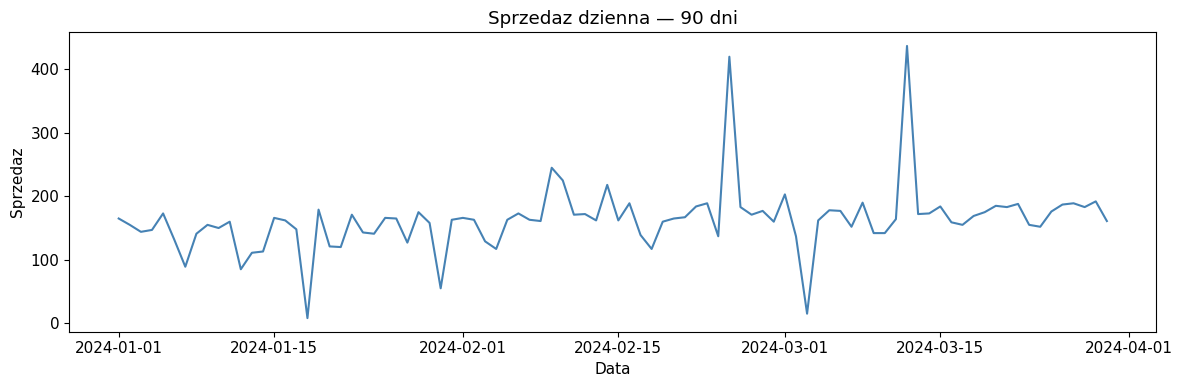

/tmp/ipykernel_17728/4246997724.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(dane_boxplot, labels=kolejnosc)


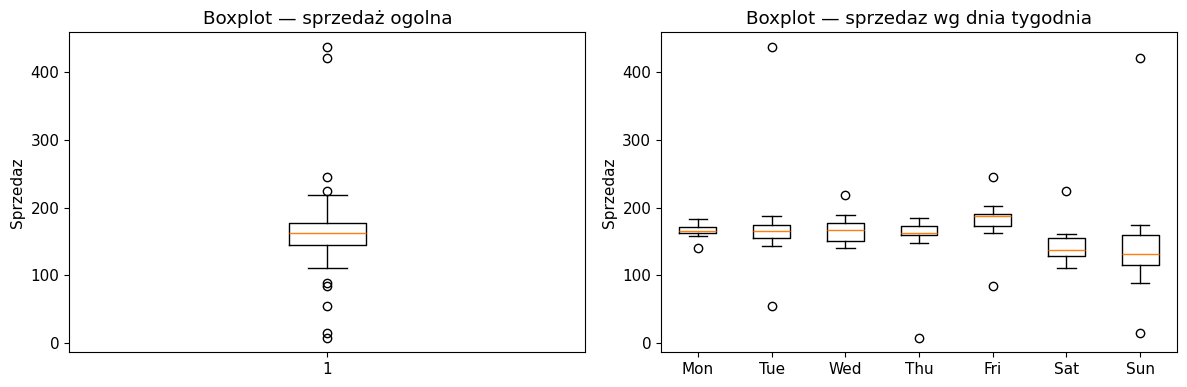


Metody wykrywania outlierow
IQR — liczba outlierow: 9


,data,sprzedaz,dzien_tygodnia,wizyty,przychod
6,2024-01-07,89,Sun,3347,3408.11
11,2024-01-12,85,Fri,2436,5121.06
17,2024-01-18,8,Thu,1600,442.06
29,2024-01-30,55,Tue,1709,3435.94
39,2024-02-09,245,Fri,8990,9310.00
40,2024-02-10,225,Sat,6505,7875.00
55,2024-02-25,420,Sun,7636,39900.00
62,2024-03-03,15,Sun,410,737.00
71,2024-03-12,437,Tue,14344,25743.12



Z-score — liczba outlierow: 2


,data,sprzedaz,dzien_tygodnia,wizyty,przychod
55,2024-02-25,420,Sun,7636,39900.00
71,2024-03-12,437,Tue,14344,25743.12



MAD — liczba outlierow: 10


,data,sprzedaz,dzien_tygodnia,wizyty,przychod
6,2024-01-07,89,Sun,3347,3408.11
11,2024-01-12,85,Fri,2436,5121.06
17,2024-01-18,8,Thu,1600,442.06
29,2024-01-30,55,Tue,1709,3435.94
39,2024-02-09,245,Fri,8990,9310.00
40,2024-02-10,225,Sat,6505,7875.00
44,2024-02-14,218,Wed,5614,13552.16
55,2024-02-25,420,Sun,7636,39900.00
62,2024-03-03,15,Sun,410,737.00
71,2024-03-12,437,Tue,14344,25743.12



Outliery wielowymiarowe


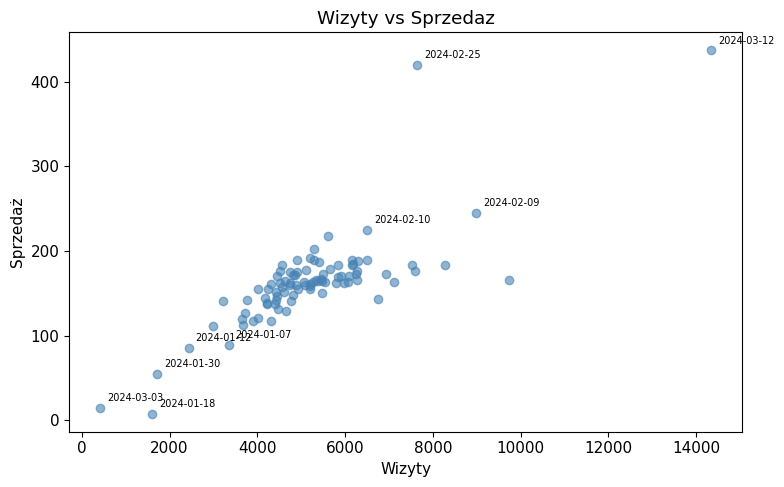


Analiza zwrotow
Top 5 dni wg % zwrotow:


,data,sprzedaz,zwroty,pct_zwrotow,dzien_tygodnia
42,2024-02-12,172,24,13.95,Mon
17,2024-01-18,8,1,12.50,Thu
43,2024-02-13,162,19,11.73,Tue
44,2024-02-14,218,22,10.09,Wed
30,2024-01-31,163,15,9.20,Wed


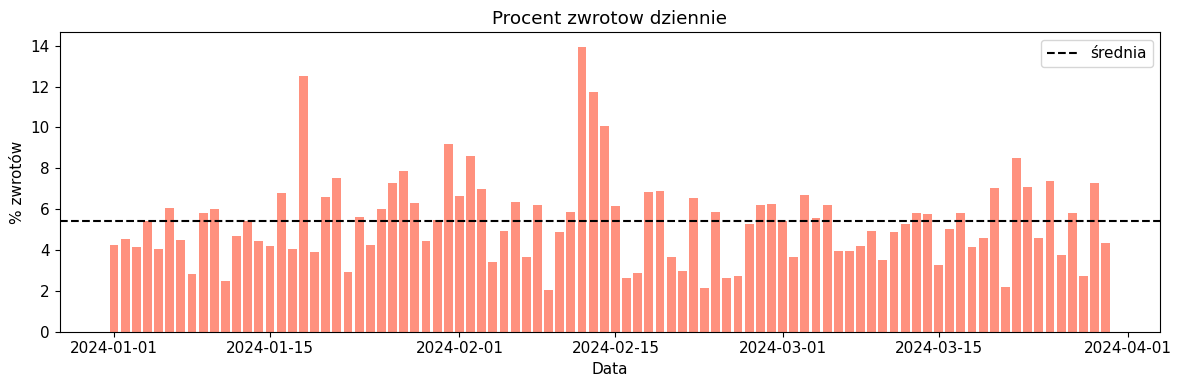

In [21]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv('sprzedaz_dzienna.csv')
df['data'] = pd.to_datetime(df['data'])

print("Statystyki opisowe")
display(df.describe())

print("\nWykresy czasowe i pudelkowe")

plt.figure(figsize=(12, 4))
plt.plot(df['data'], df['sprzedaz'], color='steelblue')
plt.title('Sprzedaz dzienna — 90 dni')
plt.xlabel('Data')
plt.ylabel('Sprzedaz')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['sprzedaz'])
axes[0].set_title('Boxplot — sprzedaż ogolna')
axes[0].set_ylabel('Sprzedaz')

kolejnosc = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dane_boxplot = [df[df['dzien_tygodnia'] == d]['sprzedaz'].values for d in kolejnosc]
axes[1].boxplot(dane_boxplot, labels=kolejnosc)
axes[1].set_title('Boxplot — sprzedaz wg dnia tygodnia')
axes[1].set_ylabel('Sprzedaz')

plt.tight_layout()
plt.show()

print("\nMetody wykrywania outlierow")

Q1 = df['sprzedaz'].quantile(0.25)
Q3 = df['sprzedaz'].quantile(0.75)
IQR = Q3 - Q1
iqr_out = df[(df['sprzedaz'] < Q1 - 1.5*IQR) | (df['sprzedaz'] > Q3 + 1.5*IQR)]
print(f"IQR — liczba outlierow: {len(iqr_out)}")
display(iqr_out[['data', 'sprzedaz', 'dzien_tygodnia', 'wizyty', 'przychod']])

z_scores = np.abs(stats.zscore(df['sprzedaz']))
zscore_out = df[z_scores > 3]
print(f"\nZ-score — liczba outlierow: {len(zscore_out)}")
display(zscore_out[['data', 'sprzedaz', 'dzien_tygodnia', 'wizyty', 'przychod']])

mad = np.median(np.abs(df['sprzedaz'] - df['sprzedaz'].median()))
mad_score = np.abs(df['sprzedaz'] - df['sprzedaz'].median()) / mad
mad_out = df[mad_score > 3.5]
print(f"\nMAD — liczba outlierow: {len(mad_out)}")
display(mad_out[['data', 'sprzedaz', 'dzien_tygodnia', 'wizyty', 'przychod']])

print("\nOutliery wielowymiarowe")

plt.figure(figsize=(8, 5))
plt.scatter(df['wizyty'], df['sprzedaz'], alpha=0.6, color='steelblue')
for _, row in iqr_out.iterrows():
    plt.annotate(str(row['data'].date()), (row['wizyty'], row['sprzedaz']),
                 fontsize=7, textcoords='offset points', xytext=(5, 5))
plt.title('Wizyty vs Sprzedaz')
plt.xlabel('Wizyty')
plt.ylabel('Sprzedaż')
plt.tight_layout()
plt.show()

print("\nAnaliza zwrotow")

df['pct_zwrotow'] = df['zwroty'] / df['sprzedaz'] * 100
print("Top 5 dni wg % zwrotow:")
display(df.nlargest(5, 'pct_zwrotow')[['data', 'sprzedaz', 'zwroty', 'pct_zwrotow', 'dzien_tygodnia']])

plt.figure(figsize=(12, 4))
plt.bar(df['data'], df['pct_zwrotow'], color='tomato', alpha=0.7)
plt.axhline(df['pct_zwrotow'].mean(), color='black', linestyle='--', label='średnia')
plt.title('Procent zwrotow dziennie')
plt.xlabel('Data')
plt.ylabel('% zwrotów')
plt.legend()
plt.tight_layout()
plt.show()

1. Statystyki opisowe — describe() pokazuje że typowa sprzedaż to ok. 163 szt./dzień, ale odchylenie standardowe wynosi 54, co sugeruje duże wahania. Maksymalna sprzedaż (437) jest ponad 2,5x wyższa od mediany.

2. Wykresy — seria czasowa pokazuje wyraźne tygodniowe cykle (niedziele niżej) oraz kilka wyraźnych skoków. Boxplot wg dnia tygodnia ujawnia, że niedziele mają systematycznie niższą sprzedaż.

3. Porównanie trzech metod:

- IQR — wykrywa 9 outlierów, zarówno niskich jak i wysokich. Dobra metoda ogólna, ale czuła na asymetrię rozkładu
- Z-score — wykrywa tylko 2 outliery (420 i 437). Bardzo konserwatywna, zakłada rozkład normalny — przy skośnych danych może przegapiać anomalie
- MAD — wykrywa 10 outlierów, najbardziej czuła. Odporna na same outliery (używa mediany zamiast średniej) — najlepsza metoda przy małych zbiorach z asymetrycznym rozkładem
Wspólne anomalie dla wszystkich trzech metod: 2024-02-25 (420 szt.) i 2024-03-12 (437 szt.)

4. Outliery wielowymiarowe — scatter wizyty vs sprzedaż ujawnia podejrzane kombinacje: 2024-01-18 ma bardzo mało wizyt (1600) i sprzedaż zaledwie 8 szt. — prawdopodobna awaria techniczna. Z kolei 2024-03-12 ma rekordowe wizyty (14344) i rekordową sprzedaż (437) jednocześnie — spójny skok, nie błąd.

5. Zwroty — dni 12–14 lutego mają wyjątkowo wysoki procent zwrotów (10–14%). Przy normalnym poziomie ok. 5% to wyraźna anomalia skupiona w jednym tygodniu.

6. Hipotezy dla każdego outliera:
- 2024-01-18 sprzedaż = 8, awaria sklepu lub bramki płatności
- 2024-01-30 sprzedaż = 55, możliwa przerwa techniczna lub błąd importu danych
- 2024-03-03 sprzedaż = 15, awaria lub błąd danych (niedziela, ale inne niedziele ~100)
- 2024-02-25 sprzedaż = 420, przychód = 39 900, kampania promocyjna lub wyprzedaż
- 2024-03-12 sprzedaż = 437, wizyty = 14 344, viralowy post, kampania lub duże zamówienie B2B
- 12–14 lutego zwroty 10–14%, wadliwa partia towaru lub błędna akcja promocyjna

7. Strategia postępowania:
- 2024-01-18 (sprzedaż = 8), oznaczyć lub usunąć, prawdopodobnie awaria — wartość nie reprezentuje rzeczywistego popytu
- 2024-01-30, 2024-03-03, oznaczyć/sprawdzić w logach — jeśli awaria, usunąć; jeśli naturalne, zachować
- 2024-02-25, 2024-03-12, zachować i oznaczyć, realne zdarzenia biznesowe — cenne do analizy sezonowości i kampanii
- 12–14 lutego (zwroty), zachować i zbadać, sygnał jakościowy — warto powiązać z konkretną partią towaru